### Test calibration when smoothing predictions from MUSE

In [19]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats

def smooth_prediction(xgrid, ygrid, loc_estimate, std):
    distr = scipy.stats.multivariate_normal(
        mean=loc_estimate,
        cov=[[std, 0], [0, std]],
    )
    # get the probability density at each gridpoints
    pmf = distr.pdf(np.dstack((xgrid, ygrid)))
    # renormalize to be a valid pmf
    pmf /= pmf.sum()
    return pmf

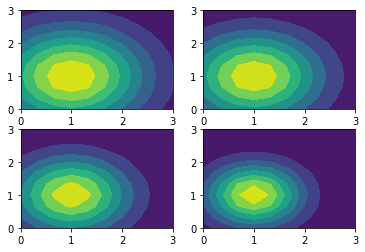

In [20]:
xgrid, ygrid = np.meshgrid(
    np.linspace(0, 3, 10),
    np.linspace(0, 3, 10)
)
smoothed_pred = lambda std: smooth_prediction(xgrid, ygrid, [1, 1], std)
fig, axs = plt.subplots(2, 2)
std_to_use = 1
for row in axs:
    for ax in row:
        ax.contourf(
            xgrid,
            ygrid,
            smoothed_pred(std_to_use)
            )
        std_to_use -= 0.2

In [21]:
def smooth_predictions(xgrid, ygrid, loc_estimates, std):
    pmf = np.zeros(xgrid.shape)
    for est in loc_estimates:
        pmf += smooth_prediction(xgrid, ygrid, est, std)
    pmf /= pmf.sum()
    return pmf

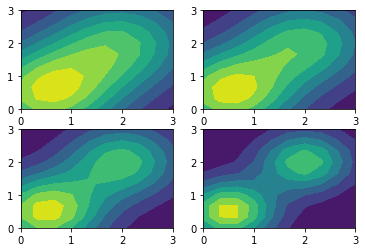

In [22]:
example_preds = [[0.5, 0.5], [2, 2]]
smoothed_by_std = lambda std: smooth_predictions(xgrid, ygrid, example_preds, std)
std_to_use = 1
fig, axs = plt.subplots(2, 2)
for row in axs:
    for ax in row:
        ax.contourf(
            xgrid,
            ygrid,
            smoothed_by_std(std_to_use)
            )
        std_to_use -= 0.2

plt.show()

simulate some data to work with for muse.

In [23]:
import muse
from scipy.io import wavfile
import glob

In [24]:
stimuli = []
sample_rates = []

for path in glob.glob('../tones/*.wav'):
    sr, stimulus = wavfile.read(path)
    stimuli.append(stimulus)
    sample_rates.append(sr)

In [25]:
print(stimuli[0].shape)

(96000,)


In [26]:
from pyroomacousticsutil import generate_dataset 

dataset = generate_dataset(stimuli, sample_rates, 0.1)

In [28]:
dataset[0].signal.shape

(4, 133962)

In [29]:
SIGMA = 0.5  # std for gaussian smoothing

from config import (
    X_DIM, Y_DIM, RESOLUTION, F_HI, F_LO, TEMP, MIC_POS
    )

xgrid, ygrid = muse.make_xy_grid(X_DIM, Y_DIM, resolution=RESOLUTION)

avg_ests = []
r_ests = []
smoothed_preds = []
for d in dataset:
    avg_est, loc_ests, _ = muse.r_est_jackknife(
        d.signal,
        d.sample_rate,
        F_LO,
        F_HI,
        TEMP,
        X_DIM,
        Y_DIM,
        RESOLUTION,
        MIC_POS
    )
    avg_ests.append(avg_est)
    r_ests.append(loc_ests)
    loc_ests = [est.reshape((2)) for est in loc_ests]
    smoothed_preds.append(smooth_predictions(xgrid, ygrid, loc_ests, SIGMA))

That took literally forever. Even with the speedup. So let's pickle everything so we never have to do that again.

In [36]:
import pickle

with open('preds.pickle', 'wb') as f:
    pickle.dump((avg_ests, r_ests, smoothed_preds), f)

In [37]:
with open('preds.pickle', 'rb') as f:
    avg_ests, r_ests, smoothed_preds = pickle.load(f)

In [38]:
def pred_contour(idx, avg_ests, ests, preds):
    plt.contourf(xgrid, ygrid, preds[idx])
    plt.plot(avg_ests[idx][0], avg_ests[idx][1], 'ro')
    for est in ests[idx]:
        plt.plot(est[0], est[1], 'go')
    plt.show()

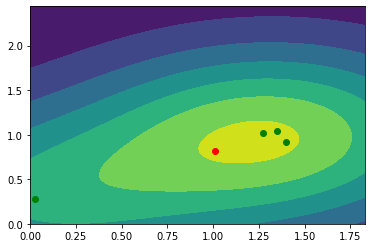

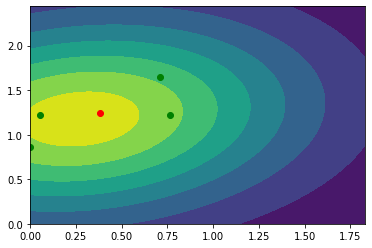

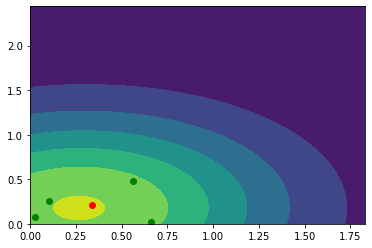

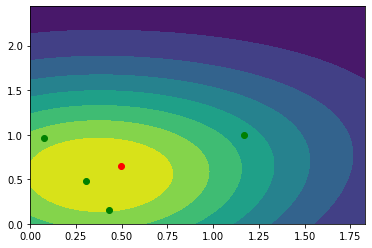

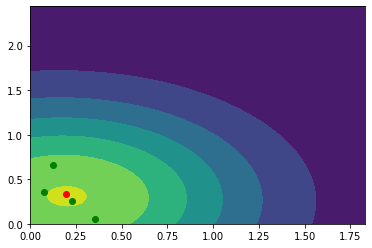

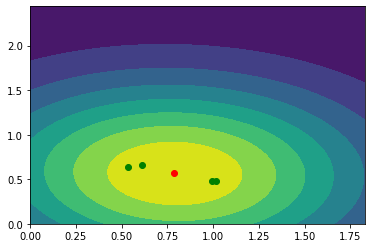

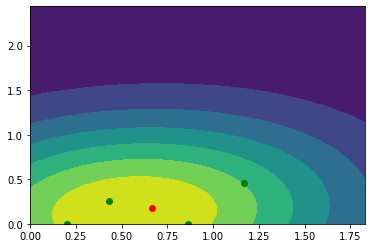

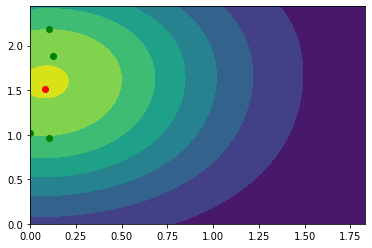

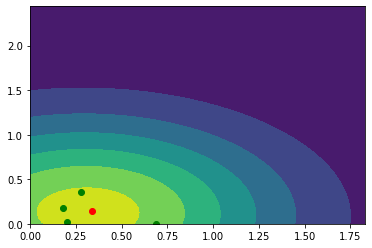

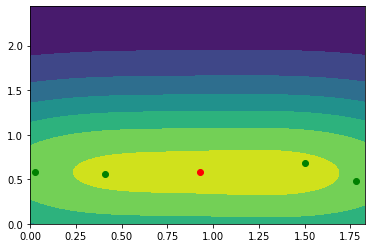

In [39]:
for i in range(10):
    pred_contour(i, avg_ests, r_ests, smoothed_preds)

now attempt to test uncertainty

In [41]:
NUM_SAMPLES = len(dataset)
locations = np.array((X_DIM, Y_DIM))[np.newaxis, :].repeat(NUM_SAMPLES, axis=0)

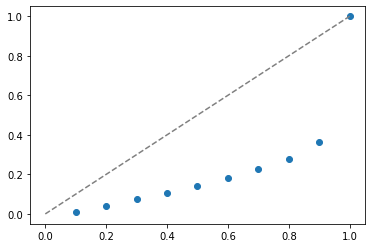

In [42]:
from calibration import calibration_curve

plt.rcParams['figure.facecolor'] = 'white'
calibration_curve(np.array(smoothed_preds), locations, xgrid, ygrid)

Guess we can't really interpret MUSE as outputting a probability distribution, even after applying Gaussian smoothing.